In [2]:
# 1️⃣ Import Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
import pandas as pd
df = pd.read_csv("clinical.csv") 
df.head()



,Age,Gender,"BMI, kg/m2",Height/m,History of Heart Failure,working place,mMRC,status of smoking,Pack History,Vaccination,Depression,Dependent,Temperature,Respiratory Rate,Heart Rate,Blood pressure,Oxygen Saturation,Sputum,FEV1,COPD GOLD
0,47,1,0,1,0,1,0,3,0,0,0,0,2,13,0,2,0.97,0,4,1
1,60,0,3,1,0,4,3,1,15,0,1,0,4,18,0,3,0.95,1,2,3
2,55,0,2,1,1,3,4,1,60,0,1,0,0,24,2,0,0.89,1,1,4
3,78,1,1,1,0,1,1,2,37,0,0,0,2,15,0,2,0.98,0,3,2
4,71,1,2,1,1,3,4,1,41,1,0,0,0,22,1,0,0.88,1,1,4


In [4]:
df.rename(columns={"COPD GOLD": "target"}, inplace=True)
print(df)


     Age  Gender  BMI, kg/m2  Height/m  History of Heart Failure  \
0     47       1           0         1                         0   
1     60       0           3         1                         0   
2     55       0           2         1                         1   
3     78       1           1         1                         0   
4     71       1           2         1                         1   
..   ...     ...         ...       ...                       ...   
219   45       0           2         1                         1   
220   76       0           3         1                         0   
221   50       1           0         1                         0   
222   75       1           2         1                         1   
223   45       1           2         1                         0   

     working place  mMRC  status of smoking  Pack History  Vaccination  \
0                1     0                  3             0            0   
1                4     3           

In [5]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace(',', '')
print(df)


     age  gender  bmi_kg/m2  height/m  history_of_heart_failure  \
0     47       1          0         1                         0   
1     60       0          3         1                         0   
2     55       0          2         1                         1   
3     78       1          1         1                         0   
4     71       1          2         1                         1   
..   ...     ...        ...       ...                       ...   
219   45       0          2         1                         1   
220   76       0          3         1                         0   
221   50       1          0         1                         0   
222   75       1          2         1                         1   
223   45       1          2         1                         0   

     working_place  mmrc  status_of_smoking  pack_history  vaccination  \
0                1     0                  3             0            0   
1                4     3                  1    

In [6]:
# 3️⃣ Drop Duplicates
df = df.drop_duplicates()


In [7]:
# 4️⃣ Separate Features and Target
X = df.drop(columns=['target'])
y = df['target']


In [8]:
# 5️⃣ Check Missing Values
print("Missing Values Summary:")
print(X.isnull().sum())


Missing Values Summary:
age                         0
gender                      0
bmi_kg/m2                   0
height/m                    0
history_of_heart_failure    0
working_place               0
mmrc                        0
status_of_smoking           0
pack_history                0
vaccination                 0
depression                  0
dependent                   0
temperature                 0
respiratory_rate            0
heart_rate                  0
blood_pressure              0
oxygen_saturation           0
sputum                      0
fev1                        0
dtype: int64


In [9]:
# 6️⃣ Detect Categorical and Numerical Columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("\nCategorical Columns:", cat_cols)
print("Numerical Columns:", num_cols)



Categorical Columns: []
Numerical Columns: ['age', 'gender', 'bmi_kg/m2', 'height/m', 'history_of_heart_failure', 'working_place', 'mmrc', 'status_of_smoking', 'pack_history', 'vaccination', 'depression', 'dependent', 'temperature', 'respiratory_rate', 'heart_rate', 'blood_pressure', 'oxygen_saturation', 'sputum', 'fev1']


In [10]:

if X.isnull().sum().sum() > 0:
    print("Missing values found — applying imputation.")
    num_imputer = SimpleImputer(strategy='mean')
    X = pd.DataFrame(num_imputer.fit_transform(X), columns=X.columns)
else:
    print("✅ No missing values found — skipping imputation.")


✅ No missing values found — skipping imputation.


In [11]:

scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])


In [12]:
# 🔟 Removing of Outliers with Isolation Forest
iso = IsolationForest(contamination=0.05, random_state=42)
outliers = iso.fit_predict(X)

X = X[outliers == 1]
y = y[outliers == 1]

print("\nShape after outlier removal:", X.shape)



Shape after outlier removal: (212, 19)


In [13]:
# 1️⃣1️⃣ Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("\n✅ Preprocessing Done")
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)



✅ Preprocessing Done
Train shape: (169, 19) Test shape: (43, 19)


In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Train model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.627906976744186

Classification Report:
               precision    recall  f1-score   support

           1       0.71      0.62      0.67        16
           2       0.50      0.55      0.52        11
           3       0.60      0.75      0.67         8
           4       0.71      0.62      0.67         8

    accuracy                           0.63        43
   macro avg       0.63      0.64      0.63        43
weighted avg       0.64      0.63      0.63        43



In [15]:
# Fix: Re-label target classes to start from 0
y_train = y_train - 1
y_test = y_test - 1


In [37]:
pip install xgboost


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:21:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ XGBoost Accuracy: 0.6511627906976745

📄 Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.69      0.73        16
           1       0.67      0.73      0.70        11
           2       0.50      0.50      0.50         8
           3       0.56      0.62      0.59         8

    accuracy                           0.65        43
   macro avg       0.63      0.63      0.63        43
weighted avg       0.66      0.65      0.65        43



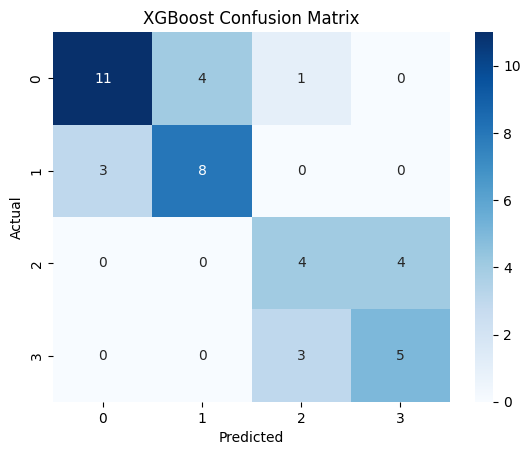

In [16]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Initialize XGBoost model
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# 2️⃣ Train the model
xgb.fit(X_train, y_train)

# 3️⃣ Predict on test set
y_pred = xgb.predict(X_test)

# 4️⃣ Evaluate
print("✅ XGBoost Accuracy:", accuracy_score(y_test, y_pred))
print("\n📄 Classification Report:\n", classification_report(y_test, y_pred))

# 5️⃣ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoost Confusion Matrix')
plt.show()


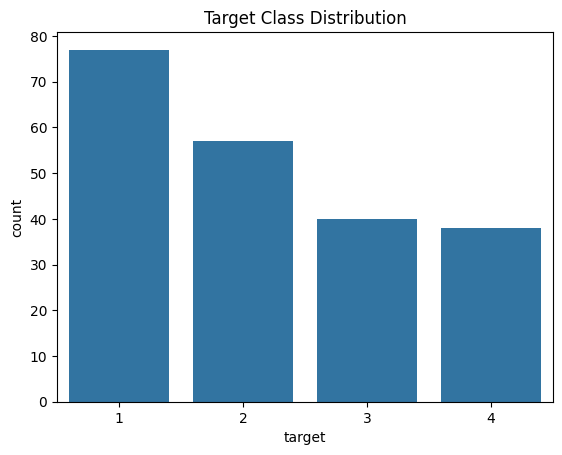

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y)
plt.title("Target Class Distribution")
plt.show()


In [19]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("After SMOTE:", np.bincount(y_train_balanced))


After SMOTE: [61 61 61 61]


In [20]:
xgb.fit(X_train_balanced, y_train_balanced)
y_pred = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))


C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:21:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.6511627906976745


In [21]:
# Insert this cell just before the Feature Engineering code block

print("X_train_balanced Columns:", X_train_balanced.columns.tolist())
print("X_test Columns:", X_test.columns.tolist())


X_train_balanced Columns: ['age', 'gender', 'bmi_kg/m2', 'height/m', 'history_of_heart_failure', 'working_place', 'mmrc', 'status_of_smoking', 'pack_history', 'vaccination', 'depression', 'dependent', 'temperature', 'respiratory_rate', 'heart_rate', 'blood_pressure', 'oxygen_saturation', 'sputum', 'fev1']
X_test Columns: ['age', 'gender', 'bmi_kg/m2', 'height/m', 'history_of_heart_failure', 'working_place', 'mmrc', 'status_of_smoking', 'pack_history', 'vaccination', 'depression', 'dependent', 'temperature', 'respiratory_rate', 'heart_rate', 'blood_pressure', 'oxygen_saturation', 'sputum', 'fev1']


In [22]:
import numpy as np # Ensure numpy is imported

# ➡️ FEATURE ENGINEERING (Corrected Code using actual column names)
# Column names are taken EXACTLY from your debug output: 'Pack History' and 'FEV1'.
PACK_COL = 'pack_history'
FEV1_COL = 'fev1'

# 1. Create the new feature: Pack History to FEV1 ratio (proxy for severity)
# We add a small constant (epsilon) to the denominator to prevent immediate division by zero
epsilon = 1e-6 
X_train_balanced['pack_per_fev1'] = X_train_balanced[PACK_COL] / (X_train_balanced[FEV1_COL] + epsilon)
X_test['pack_per_fev1'] = X_test[PACK_COL] / (X_test[FEV1_COL] + epsilon)

# 2. Handle any resultant infinite values created during division
# Impute NaN/Inf (use mean)
X_train_balanced.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

X_train_balanced['pack_per_fev1'].fillna(X_train_balanced['pack_per_fev1'].mean())
X_test['pack_per_fev1'].fillna(X_test['pack_per_fev1'].mean())

print("✅ Feature Engineering Complete. New feature 'pack_per_fev1' added.")


✅ Feature Engineering Complete. New feature 'pack_per_fev1' added.


In [23]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import make_scorer, accuracy_score, f1_score
from sklearn.ensemble import RandomForestClassifier # Ensure this is imported for the Stacking

# Since this is a Multiclass problem, let's use accuracy as the primary metric for GridSearchCV.
scorer = make_scorer(accuracy_score) 

# --- A. Tune XGBoost ---
print("\n--- Tunning XGBoost Classifier ---")

# Define a more thorough search space for XGBoost
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'gamma': [0, 0.1, 0.2] 
}

xgb_model = XGBClassifier(
    use_label_encoder=False, 
    eval_metric='mlogloss', 
    objective='multi:softmax', 
    random_state=42
)

xgb_grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=xgb_param_grid,
    scoring=scorer,
    cv=5, # 5-fold cross-validation
    n_jobs=-1,
    verbose=1
)

# X_train_balanced and y_train_balanced are ready from the SMOTE cell
xgb_grid_search.fit(X_train_balanced, y_train_balanced)
best_xgb_tuned = xgb_grid_search.best_estimator_

print(f"Best Tuned XGBoost Accuracy (CV): {xgb_grid_search.best_score_:.4f}")
print(f"Best XGBoost Params: {xgb_grid_search.best_params_}")


# --- B. Tune K-Nearest Neighbors (KNN) ---
print("\n--- Tunning K-Nearest Neighbors (KNN) ---")

# Define search space for KNN
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],  # Tune 'k'
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn_model = KNeighborsClassifier()

knn_grid_search = GridSearchCV(
    estimator=knn_model,
    param_grid=knn_param_grid,
    scoring=scorer,
    cv=5,
    n_jobs=-1,
    verbose=1
)

knn_grid_search.fit(X_train_balanced, y_train_balanced)
best_knn_tuned = knn_grid_search.best_estimator_

print(f"Best Tuned KNN Accuracy (CV): {knn_grid_search.best_score_:.4f}")
print(f"Best KNN Params: {knn_grid_search.best_params_}")



--- Tunning XGBoost Classifier ---
Fitting 5 folds for each of 81 candidates, totalling 405 fits


C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:22:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Tuned XGBoost Accuracy (CV): 0.7873
Best XGBoost Params: {'gamma': 0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300}

--- Tunning K-Nearest Neighbors (KNN) ---
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Tuned KNN Accuracy (CV): 0.8081
Best KNN Params: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}


In [24]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neighbors import KNeighborsClassifier

# Define the best model using the parameters found via tuning
# Best KNN Params: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
best_knn_final = KNeighborsClassifier(
    n_neighbors=5, 
    weights='distance', 
    metric='manhattan'
)

# Train on the full balanced training set
best_knn_final.fit(X_train_balanced, y_train_balanced)

# Predict on the UNSEEN test set
y_pred_knn = best_knn_final.predict(X_test)
final_knn_accuracy = accuracy_score(y_test, y_pred_knn)
final_knn_report = classification_report(y_test, y_pred_knn)

print("-----------------------------------------------------")
print(f"🏆 Final Clinical Model (KNN) Test Accuracy: {final_knn_accuracy:.4f}")
print("\nClassification Report (Key Metric for Multiclass):\n", final_knn_report)
print("-----------------------------------------------------")


-----------------------------------------------------
🏆 Final Clinical Model (KNN) Test Accuracy: 0.7907

Classification Report (Key Metric for Multiclass):
               precision    recall  f1-score   support

           0       0.78      0.88      0.82        16
           1       0.78      0.64      0.70        11
           2       0.78      0.88      0.82         8
           3       0.86      0.75      0.80         8

    accuracy                           0.79        43
   macro avg       0.80      0.78      0.79        43
weighted avg       0.79      0.79      0.79        43

-----------------------------------------------------


In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import VotingClassifier, RandomForestClassifier # Import Voting

# --- 1. Clean Data and Create Binary Target ---
df_new = pd.read_csv("clinical.csv") 

# Standardize column names (as per your notebook)
df_new.columns = df_new.columns.str.strip().str.lower().str.replace(' ', '_').str.replace(',', '')

# 1a. Create the new BINARY target column
# 0 = Mild/Moderate (GOLD 1, 2); 1 = Severe/Very Severe (GOLD 3, 4)
df_new['severe_copd'] = df_new['copd_gold'].apply(lambda x: 0 if x in [1, 2] else 1)

# Drop the old target column
X = df_new.drop(columns=['copd_gold', 'severe_copd'])
y = df_new['severe_copd']

# 1b. Train-Test Split (using stratified sampling is key here)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 1c. SMOTE for Balancing
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"Original 4-Class Problem converted to 2-Class Problem.")
print(f"New Target Distribution (0: Mild/Moderate, 1: Severe/Very Severe): {y_train_balanced.value_counts().values}")


Original 4-Class Problem converted to 2-Class Problem.
New Target Distribution (0: Mild/Moderate, 1: Severe/Very Severe): [112 112]


In [26]:
# --- 2. Implement Simple Voting Ensemble (Using Your Best Parameters) ---

# Define Best Models (using your highly successful tuned parameters)
# KNN (Your Champion Model: 0.8081 CV Accuracy)
knn_clf = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='manhattan')

# XGBoost (Your Second Best Model: 0.7873 CV Accuracy)
xgb_clf = XGBClassifier(
    gamma=0, 
    learning_rate=0.1, 
    max_depth=3, 
    n_estimators=300,
    use_label_encoder=False,
    eval_metric='logloss', # Use binary metric for 2-class problem
    random_state=42
)

# Random Forest (A robust, diverse model for the ensemble)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)


# Implement Simple Voting Ensemble (voting='soft' averages prediction probabilities)
voting_clf = VotingClassifier(
    estimators=[
        ('knn', knn_clf),
        ('xgb', xgb_clf),
        ('rf', rf_clf)
    ],
    voting='soft', 
    n_jobs=-1
)

# Train and Evaluate
print("\n--- Training Final Voting Ensemble for Binary Severity Staging ---")
voting_clf.fit(X_train_balanced, y_train_balanced)

y_pred_voting = voting_clf.predict(X_test)
final_voting_accuracy = accuracy_score(y_test, y_pred_voting)
final_voting_report = classification_report(y_test, y_pred_voting)


print("-----------------------------------------------------")
print(f"🏆 Final Binary Severity (0/1) Model Accuracy: {final_voting_accuracy:.4f}")
print("\nClassification Report:\n", final_voting_report)
print("-----------------------------------------------------")



--- Training Final Voting Ensemble for Binary Severity Staging ---
-----------------------------------------------------
🏆 Final Binary Severity (0/1) Model Accuracy: 0.9111

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.89      0.93        28
           1       0.84      0.94      0.89        17

    accuracy                           0.91        45
   macro avg       0.90      0.92      0.91        45
weighted avg       0.92      0.91      0.91        45

-----------------------------------------------------


In [29]:
voting_clf.fit(X_train_balanced, y_train_balanced) 

# 1. Calculate the probability array (P_clinical)
# We need the probability of the positive class (1: Severe COPD)
P_clinical = voting_clf.predict_proba(X_test)[:, 1]

# 2. Define the true labels array
y_test_clinical = y_test.values  # Assuming y_test is a pandas Series from cell 49

# 3. Define the final model object to save
xgb_clinical_model_object = voting_clf

print("✅ P_clinical and y_test_clinical calculated.")
print(f"P_clinical array size: {P_clinical.shape[0]}")


✅ P_clinical and y_test_clinical calculated.
P_clinical array size: 45


In [30]:
import joblib
import numpy as np

print("--- Saving Clinical Model (Model 1) Outputs ---")

# 1. Save the trained Voting Classifier model object
joblib.dump(xgb_clinical_model_object, 'clinical_model.joblib')

# 2. Save the probability array (P_clinical)
np.save('P_clinical.npy', P_clinical)

# 3. Save the true labels (y_test) for the final ensemble evaluation
np.save('y_test_ensemble_labels.npy', y_test_clinical)

print("✅ Clinical Model and outputs saved successfully.")


--- Saving Clinical Model (Model 1) Outputs ---
✅ Clinical Model and outputs saved successfully.
